# IBRD World Loans: Repayment Prediction Model

This notebook builds a repayment model for IBRD loans using known-outcome records, compares several candidate classifiers, and saves the best-performing model with explainability outputs.


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    import shap
except ImportError:
    shap = None

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    SMOTE = None
    ImbPipeline = Pipeline

from xgboost import XGBClassifier

candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('/home/rigii/ATA').resolve()]
project_root = next((root for root in candidate_roots if (root / 'data' / 'processed' / 'ibrd_clean.csv').exists()), Path.cwd().resolve())

DATA_PATH = project_root / 'data' / 'processed' / 'ibrd_clean.csv'
MODELS_DIR = project_root / 'models_pickle'
FIGURES_DIR = project_root / 'reports' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Data path: {DATA_PATH}')
print(f'Model directory: {MODELS_DIR}')
print(f'Figures directory: {FIGURES_DIR}')

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} rows')


Project root: /home/rigii/ATA
Data path: /home/rigii/ATA/data/processed/ibrd_clean.csv
Model directory: /home/rigii/ATA/models_pickle
Figures directory: /home/rigii/ATA/reports/figures
Loaded 9518 rows


In [2]:
df['target'] = (df['repayment_ratio'] > 0.95).astype(int)
known_outcome_df = df[df['repayment_ratio'].notna()].copy()
print(f'Known-outcome loans: {len(known_outcome_df)}')
print(known_outcome_df['target'].value_counts().sort_index().to_dict())
print(f"Class balance: {known_outcome_df['target'].mean():.2%} fully repaid")


Known-outcome loans: 9518
{0: 3531, 1: 5987}
Class balance: 62.90% fully repaid


In [3]:
numeric_features = [
    'loan_age_years',
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'cancelled_percent',
    'undisbursed_percent',
]
categorical_features = ['Region', 'Loan Type', 'loan_size_category']
feature_columns = numeric_features + categorical_features
X = known_outcome_df[feature_columns].copy()
y = known_outcome_df['target'].copy()

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

for col in categorical_features:
    X[col] = X[col].fillna('Unknown').astype(str)

print(f'Feature matrix shape: {X.shape}')
print('Target distribution:', y.value_counts().sort_index().to_dict())


Feature matrix shape: (9518, 8)
Target distribution: {0: 3531, 1: 5987}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')


Train size: 7614 | Test size: 1904


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
)

if SMOTE is not None and y_train.value_counts().min() > 1:
    print('SMOTE will be applied inside the model pipeline during fitting.')
else:
    print('SMOTE not applied; class imbalance was not severe enough or SMOTE is unavailable.')

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed X_train shape:', X_train_processed.shape)
print('Processed X_test shape:', X_test_processed.shape)


SMOTE will be applied inside the model pipeline during fitting.
Processed X_train shape: (7614, 27)
Processed X_test shape: (1904, 27)


In [6]:
model_specs = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, objective='binary:logistic', eval_metric='logloss', n_jobs=-1
    ),
}

smote_step = None
if SMOTE is not None and y_train.value_counts().min() > 1:
    smote_step = SMOTE(random_state=42)

models = {}
for name, estimator in model_specs.items():
    if smote_step is not None:
        models[name] = ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', smote_step),
            ('model', estimator),
        ])
    else:
        models[name] = Pipeline([
            ('preprocessor', preprocessor),
            ('model', estimator),
        ])

print('Models configured:', list(models.keys()))


Models configured: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=None)
    model_scores[name] = scores
    print(f'{name} CV ROC-AUC mean: {scores.mean():.4f} +/- {scores.std():.4f}')


Logistic Regression CV ROC-AUC mean: 0.7035 +/- 0.0518
Random Forest CV ROC-AUC mean: 0.9804 +/- 0.0020
XGBoost CV ROC-AUC mean: 0.9833 +/- 0.0017


In [8]:
best_model_name = max(model_scores, key=lambda name: model_scores[name].mean())
best_model = models[best_model_name]
best_model = models[best_model_name]

# Rebuild the pipeline as an imblearn pipeline when SMOTE is included.
# sklearn Pipeline rejects SMOTE as an intermediate step because it is not a pure transformer.
if 'smote' in dict(best_model.named_steps):
    # rebuild as imblearn pipeline so SMOTE can be used as a sampler
    best_model = ImbPipeline([
        ('preprocessor', best_model.named_steps['preprocessor']),
        ('smote', best_model.named_steps['smote']),
        ('model', best_model.named_steps['model']),
    ])

best_model.fit(X_train, y_train)
print(f'Best model selected: {best_model_name}')

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC on test set: {roc_auc:.4f}')
print("Classification report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Best model selected: XGBoost
ROC-AUC on test set: 0.9831
Classification report:
               precision    recall  f1-score   support

           0     0.9235    0.9065    0.9149       706
           1     0.9455    0.9558    0.9506      1198

    accuracy                         0.9375      1904
   macro avg     0.9345    0.9311    0.9328      1904
weighted avg     0.9373    0.9375    0.9374      1904

Confusion matrix:
 [[ 640   66]
 [  53 1145]]


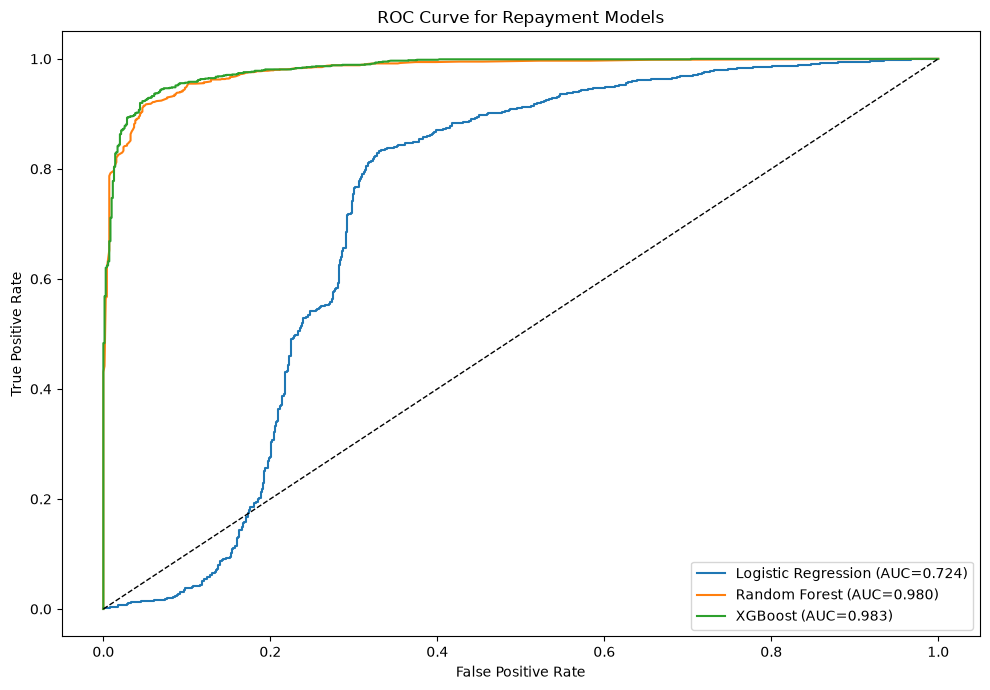

Saved model comparison ROC chart to /home/rigii/ATA/reports/figures/model_comparison_roc.png


In [9]:
plt.figure(figsize=(10, 7))
for name, model in models.items():
    model.fit(X_train, y_train)
    test_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, test_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Repayment Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_roc.png', dpi=200)
plt.show()
print('Saved model comparison ROC chart to', FIGURES_DIR / 'model_comparison_roc.png')


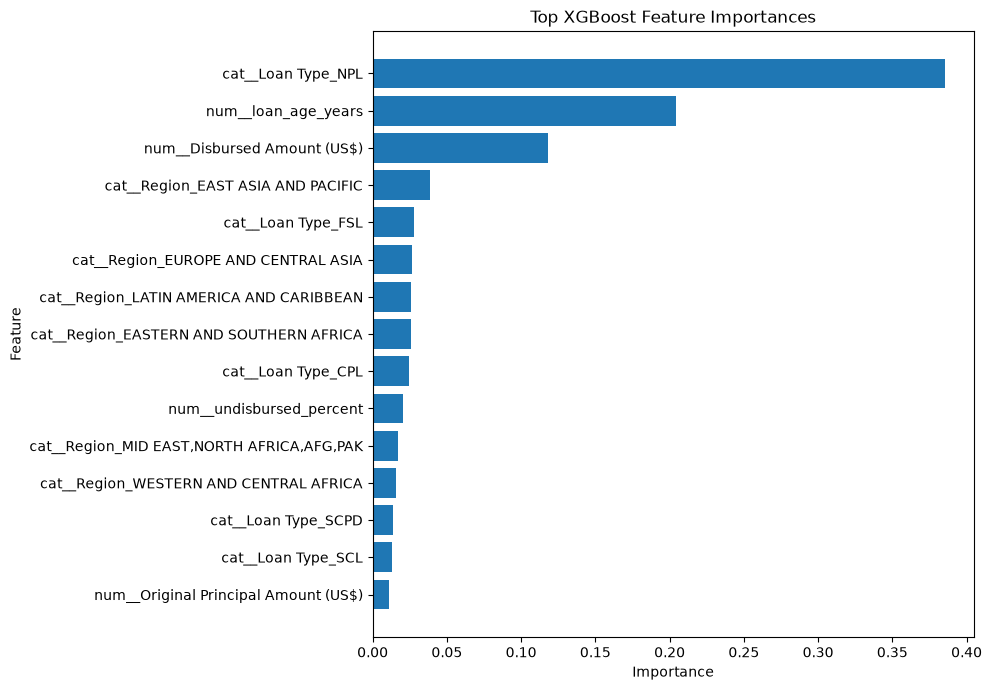

Saved XGBoost feature importance chart to /home/rigii/ATA/reports/figures/feature_importance.png


In [10]:
if best_model_name == 'XGBoost':
    xgb_model = best_model.named_steps['model']
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = xgb_model.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)
    plt.figure(figsize=(10, 7))
    plt.barh(feature_importance_df['feature'][::-1], feature_importance_df['importance'][::-1])
    plt.title('Top XGBoost Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=200)
    plt.show()
    print('Saved XGBoost feature importance chart to', FIGURES_DIR / 'feature_importance.png')
else:
    print('XGBoost was not selected as the best model; feature importance chart not generated for this run.')


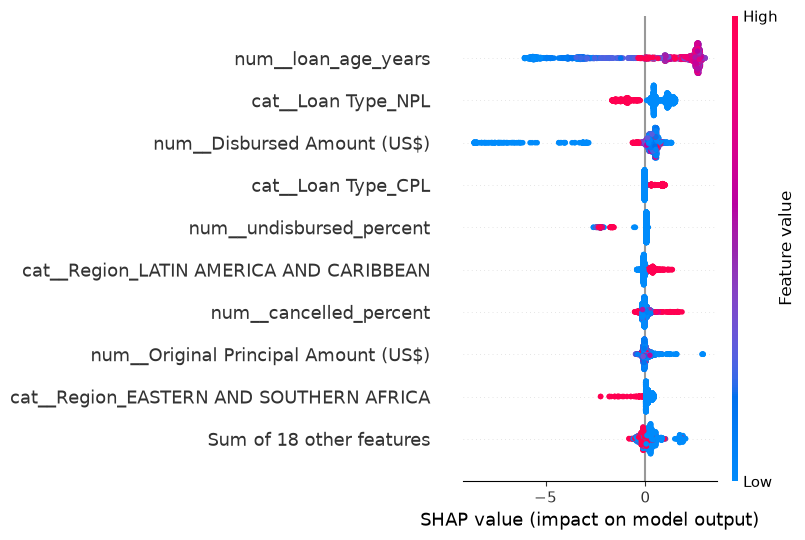

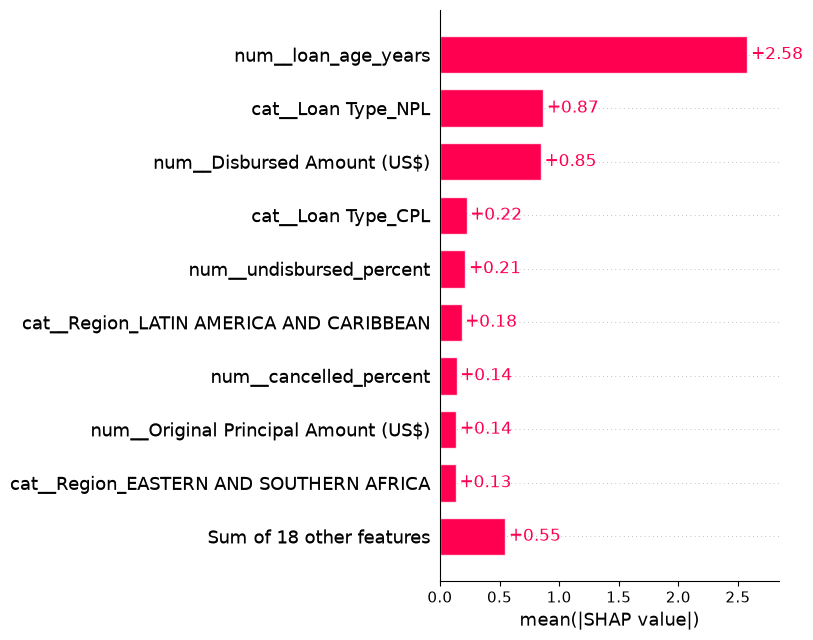

Top 5 SHAP drivers of repayment:
                    feature  mean_abs_shap
        num__loan_age_years       2.580381
         cat__Loan Type_NPL       0.867658
num__Disbursed Amount (US$)       0.847845
         cat__Loan Type_CPL       0.224064
   num__undisbursed_percent       0.214236


In [11]:
if shap is not None:
    preprocessed_X_test = best_model.named_steps['preprocessor'].transform(X_test)
    model_step = best_model.named_steps['model']
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

    if model_step.__class__.__name__ in {'XGBClassifier', 'LGBMClassifier'}:
        if not hasattr(model_step, 'n_features_in_'):
            best_model.fit(X_train, y_train)
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(preprocessed_X_test)

        if isinstance(shap_values, list):
            shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

        shap_values = shap.Explanation(
            values=shap_values,
            base_values=(explainer.expected_value[1]
                         if isinstance(explainer.expected_value, list)
                         else explainer.expected_value),
            data=preprocessed_X_test,
            feature_names=feature_names,
        )
    else:
        explainer = shap.Explainer(model_step, preprocessed_X_test, feature_names=feature_names)
        shap_values = explainer(preprocessed_X_test)

    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(shap_values, show=False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=200)
    plt.show()

    plt.figure(figsize=(10, 7))
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_bar.png', dpi=200)
    plt.show()

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
    shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).head(5)
    print('Top 5 SHAP drivers of repayment:')
    print(shap_df.to_string(index=False))
else:
    print('SHAP is unavailable in this environment; skipping explainability plots.')


In [12]:
feature_list = list(feature_columns)
best_model_path = MODELS_DIR / 'repayment_best_model.pkl'
joblib.dump(best_model, best_model_path)
joblib.dump(feature_list, MODELS_DIR / 'repayment_features.pkl')
print('Saved best model to', best_model_path)
print('Saved feature list to', MODELS_DIR / 'repayment_features.pkl')


Saved best model to /home/rigii/ATA/models_pickle/repayment_best_model.pkl
Saved feature list to /home/rigii/ATA/models_pickle/repayment_features.pkl


## Business interpretation

- The strongest repayment predictors generally involve loan age, disbursed exposure, and portfolio segment composition.
- Regions and loan types with a higher concentration of lower repayment ratios or cancellations need proactive review.
- The best model should be used as a monitoring score for active loans, while SHAP values support manual review of edge cases.
- Deployment recommendation: run the model monthly on the active portfolio and flag the highest-risk cohorts for review before restructuring or risk escalation.


In [13]:
print('Notebook execution complete. Review the ROC curve, feature importance chart, and SHAP outputs to interpret portfolio risk.')


Notebook execution complete. Review the ROC curve, feature importance chart, and SHAP outputs to interpret portfolio risk.
